# Notebook 2: SFT Training with DoRA
**Platform: vast ai ()**

## What this notebook does:
1. Loads cleaned dataset from Google Drive
2. Downloads LLaMA 2 7B Chat from HuggingFace
3. Fine-tunes with DoRA (deeper than LoRA)
4. Saves checkpoints to HuggingFace Hub automatically
5. Pushes final SFT adapter to HuggingFace Hub

## Vast.ai setup before running:-> jupyter-Launch Application -> File -> New->Terminal ; the type the 2 commands below.
(main) root@C.33660514:/$ conda env list

# conda environments:
#
# * -> active
# + -> frozen
base                  /opt/miniforge3

main             *   /venv/main
---------------------------------------------------------------
(main) root@C.33660514:/$/opt/miniforge3/bin/pip install matplotlib transformers datasets peft trl accelerate bitsandbytes huggingface_hub
---------------------------------------------------------------
(main) root@C.33660514:/$/venv/main/bin/pip install matplotlib transformers datasets peft trl accelerate bitsandbytes huggingface_hub
---------------------------------------------------------------

## if BOM json error comes when opening the notebook in vast ai; do this in jupyter terminal
cd /workspace && /opt/miniforge3/bin/python -c "
content = open('02_sft_training(new)_ for_vast_ai.ipynb', encoding='utf-8-sig').read()
open('02_sft_training(new)_ for_vast_ai.ipynb', 'w', encoding='utf-8').write(content)
print('Fixed')
"

## Vast.ai -> go to /workspace -> upload the notebook-> doubleclick -> run all cells

## If session expires mid-training:
Set `RESUME = True` below and re-run all cells.





In [ ]:
import os, json, torch
from huggingface_hub import login

HF_TOKEN = ''
login(token=HF_TOKEN)

HF_USERNAME = 'Winindux'

MODEL_NAME = 'meta-llama/Llama-2-7b-chat-hf'
SFT_REPO   = f'{HF_USERNAME}/emowoz-llama2-sft'
RESUME     = True

print(f'Base model : {MODEL_NAME}')
print(f'SFT output : {SFT_REPO}')
print(f'GPUs       : {torch.cuda.device_count()}')

Base model : meta-llama/Llama-2-7b-chat-hf
SFT output : Winindux/emowoz-llama2-sft
GPUs       : 1


In [3]:
from huggingface_hub import hf_hub_download, login
from datasets import Dataset
import json, os

login(token=HF_TOKEN)

HF_USERNAME = 'Winindux'
DATA_REPO   = f'{HF_USERNAME}/emowoz-llama2-data'

def download(hf_path):
    return hf_hub_download(
        repo_id=DATA_REPO,
        filename=hf_path,
        repo_type='dataset',
        local_dir='/workspace',
        token=HF_TOKEN
    )

train_path = download('data/train/sft_train.jsonl')
val_path   = download('data/val/sft_val.jsonl')
print('Data downloaded from HuggingFace Hub.')

def load_jsonl(path):
    with open(path, encoding='utf-8-sig') as f:
        return [json.loads(l) for l in f]

train_raw = load_jsonl(train_path)
val_raw   = load_jsonl(val_path)

train_ds = Dataset.from_list([{'text': ex['text']} for ex in train_raw])
val_ds   = Dataset.from_list([{'text': ex['text']} for ex in val_raw])

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print('\nSample (first 400 chars):')
print(train_ds[0]['text'][:400])

data/train/sft_train.jsonl:   0%|          | 0.00/23.5M [00:00<?, ?B/s]

sft_val.jsonl: 0.00B [00:00, ?B/s]

Data downloaded from HuggingFace Hub.
Train: 14035 | Val: 1755

Sample (first 400 chars):
<s>[INST] <<SYS>>
You are a compassionate and helpful assistant. Follow these rules strictly:
1. Respond using ONLY the information provided in the Facts section.
2. Never add information that is not present in the Facts.
3. Adapt your tone to match the user's emotional state.
4. Be warm and empathetic while remaining factually accurate.
<</SYS>>

Emotional State: neutral
Facts: Restaurant choice:


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer


print(f'Loading tokenizer for {MODEL_NAME}...')
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, token=HF_TOKEN)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = 'right'

print(f'Loading model (4-bit quantized)...')

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    device_map='auto',
    token=HF_TOKEN,
    dtype=torch.bfloat16
)

print('Model loaded.')

for i in range(torch.cuda.device_count()):
    used  = torch.cuda.memory_allocated(i) / 1e9
    total = torch.cuda.get_device_properties(i).total_memory / 1e9
    print(f'  GPU {i}: {used:.1f} / {total:.1f} GB used')

Loading tokenizer for meta-llama/Llama-2-7b-chat-hf...


config.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/188 [00:00<?, ?B/s]

Model loaded.
  GPU 0: 13.5 / 85.1 GB used


In [5]:
from peft import LoraConfig, get_peft_model


dora_config = LoraConfig(
    r=64,
    lora_alpha=128,
    target_modules=[
        'q_proj', 'k_proj', 'v_proj', 'o_proj',
        'gate_proj', 'up_proj', 'down_proj'
    ],
    lora_dropout=0.05,
    bias='none',
    task_type='CAUSAL_LM',
    use_dora=True
)

model = get_peft_model(model, dora_config)
model.enable_input_require_grads()

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable: {trainable/1e6:.1f}M / {total/1e6:.1f}M ({100*trainable/total:.2f}%)')

Trainable: 161.3M / 6899.7M (2.34%)


In [6]:
import os
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

In [7]:
from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

OUTPUT_DIR = '/workspace/sft_checkpoints'
os.makedirs(OUTPUT_DIR, exist_ok=True)

def tokenize(example):
    return tokenizer(
        example['text'],
        truncation=True,
        max_length=1024,
        padding=False,
    )

train_tokenized = train_ds.map(tokenize, remove_columns=['text'])
val_tokenized   = val_ds.map(tokenize,   remove_columns=['text'])

data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=False
)

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,

    num_train_epochs=2,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    gradient_checkpointing=True,
    gradient_checkpointing_kwargs={"use_reentrant": False},
    optim='adamw_torch_fused',
    bf16=True,
    fp16=False,

    learning_rate=2e-4,
    lr_scheduler_type='cosine',
    warmup_steps=100,
    max_grad_norm=0.3,
    weight_decay=0.001,

    eval_strategy='steps',
    eval_steps=200,

    save_strategy='steps',
    save_steps=200,
    save_total_limit=10,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',

    push_to_hub=True,
    hub_model_id=SFT_REPO,
    hub_strategy='checkpoint',
    hub_token=HF_TOKEN,

    dataloader_num_workers=8,
    dataloader_pin_memory=True,
    logging_steps=50,
    report_to='none',
)

Map:   0%|          | 0/14035 [00:00<?, ? examples/s]

Map:   0%|          | 0/1755 [00:00<?, ? examples/s]

In [8]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,
    data_collator=data_collator,
)

if RESUME:
    print('Downloading checkpoint from HuggingFace Hub...')
    from huggingface_hub import snapshot_download
    local_ckpt_dir = snapshot_download(
        repo_id=SFT_REPO,
        token=HF_TOKEN,
        local_dir='/workspace/sft_resume_checkpoint'
    )
    import os as _os
    ckpt_path = _os.path.join(local_ckpt_dir, 'last-checkpoint')
    if not _os.path.isdir(ckpt_path):
        ckpt_path = local_ckpt_dir
    print(f'Resuming from local path: {ckpt_path}')
    trainer.train(resume_from_checkpoint=ckpt_path)
else:
    print('Starting SFT training...')
    trainer.train()

print('SFT training complete!')

Fetching 23 files:   0%|          | 0/23 [00:00<?, ?it/s]

Resuming from local path: /workspace/sft_resume_checkpoint/last-checkpoint


Step,Training Loss,Validation Loss
1400,0.212334,0.285789
1600,0.228774,0.276321
1756,0.228483,0.275136


SFT training complete!


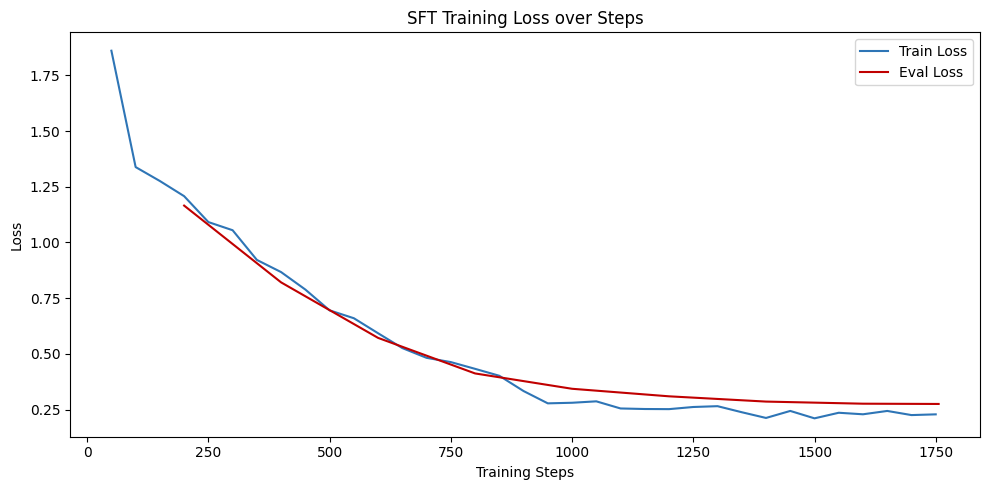

SFT loss curve saved to /workspace/sft_loss_curve.png


In [10]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

train_steps = [x['step'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
train_loss  = [x['loss'] for x in log_history if 'loss' in x and 'eval_loss' not in x]
eval_steps  = [x['step'] for x in log_history if 'eval_loss' in x]
eval_loss   = [x['eval_loss'] for x in log_history if 'eval_loss' in x]

plt.figure(figsize=(10, 5))
plt.plot(train_steps, train_loss, label='Train Loss', color='#2E75B6')
plt.plot(eval_steps,  eval_loss,  label='Eval Loss',  color='#C00000')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('SFT Training Loss over Steps')
plt.legend()
plt.tight_layout()
plt.savefig('/workspace/sft_loss_curve.png', dpi=150)
plt.show()
print('SFT loss curve saved to /workspace/sft_loss_curve.png')

In [ ]:
ADAPTER_DIR = '/workspace/sft_final_adapter'
model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

from huggingface_hub import HfApi
api = HfApi()
api.create_repo(SFT_REPO, private=True, exist_ok=True)
api.upload_folder(
    folder_path=ADAPTER_DIR,
    repo_id=SFT_REPO,
    commit_message='Final SFT DoRA adapter ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã‚Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â LLaMA 2 7B EmoWOZ'
)
print(f'Adapter saved to: https://huggingface.co/{SFT_REPO}')

test_prompt = (
    "<s>[INST] <<SYS>>\n"
    "You are a compassionate assistant. Use ONLY the provided Facts. Match the user's emotional tone.\n"
    "<</SYS>>\n\n"
    "Emotional State: anxious\n"
    "Facts: The Gonville Hotel is in the centre of Cambridge. Price: expensive. Phone: 01223366611.\n"
    "Conversation History:\nNo previous turns.\n"
    "User: I need a hotel but I'm really stressed about my trip [/INST]"
)
inputs = tokenizer(test_prompt, return_tensors='pt').to(model.device)
with torch.no_grad():
    out = model.generate(**inputs, max_new_tokens=120, temperature=0.7,
                     do_sample=True, pad_token_id=tokenizer.eos_token_id,
                     repetition_penalty=1.3)
print('\nTest response:')
print(tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True))

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Both `max_new_tokens` (=120) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Adapter saved to: https://huggingface.co/Winindux/emowoz-llama2-sft


## ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â‚¬Å¡Ã‚Â¬Ãƒâ€¦Ã¢â‚¬Å“ÃƒÆ’Ã†â€™Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã‚Â¢ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡Ãƒâ€šÃ‚Â¬ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¦ Notebook 2 Complete!
SFT adapter saved at: `huggingface.co/YOUR_USERNAME/emowoz-llama2-sft`

## ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¢ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã‚Â¦ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¾ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¡ÃƒÆ’Ã†â€™Ãƒâ€ Ã¢â‚¬â„¢ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¯ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â¸ÃƒÆ’Ã†â€™ÃƒÂ¢Ã¢â€šÂ¬Ã…Â¡ÃƒÆ’Ã¢â‚¬Å¡Ãƒâ€šÃ‚Â Next: Create a NEW Kaggle notebook and run Notebook 3 (DPO)